In [328]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt
from scipy.integrate import quad
from scipy.differentiate import derivative
import scipy.integrate as integrate
from matplotlib import animation
from matplotlib.animation import PillowWriter
import patchworklib as pw
from sympy.codegen import Print

In [329]:
#time varying function for control

def f(t,args):
    T=args['T']
    return t/T #np.sin(np.pi * t / (2 * T))**2 #t/T

In [330]:
a = 0.5
b = 0.1 #time-independent coupling constant
c = 0.3 #to avoid system-crossing between first and second eigenenergy level
d = 1
T = 5000 #time evolution interval
args = {'T': T}
t=0
# t_list=np.linspace(0,T,1001) #time-stepping

In [331]:
#Static and Dynamic Hamiltonian
data=[[a,b,0],[b,-a,c],[0,c,0]]
H_static=qt.Qobj(data) #Static Hamiltonian

def H_dynamic(b):
    data1=[[-1,0,0],[0,1,0],[0,0,1*d]]
    matrix1=qt.Qobj(data1)
    return matrix1 #Dynamic Hamiltonian


In [332]:
#initial hamiltonian
H_t=H_static+(f(t,args)*H_dynamic(b))
eigenvalue,eigenvector=H_t.eigenstates()
psi0=eigenvector[0]
#total hamiltonian
H_total=[H_static,[H_dynamic(b),f]]

In [333]:
T1=np.linspace(100,5000,100)
listy=[]
groundy=[]
firsty=[]
secondy=[]
errors_fidelity_list_full=[]
for T_curr in T1:
    args['T'] = T_curr
    t_list1 = np.linspace(0, T_curr, 200)
    listy.append(t_list1)
    final = qt.sesolve(H_total, psi0, t_list1, args=args)
    errors_fidelity_list=[]
    ground_temp,first_temp,second_temp=[],[],[]

    for i,t in enumerate(t_list1):
        f_val = f(t, args)
        H_t = H_static + f_val * H_dynamic(b)
        evals, estates = H_t.eigenstates()
        ground_temp.append(evals[0])
        first_temp.append(evals[1])
        second_temp.append(evals[2])
        fidelity = np.abs(estates[0].overlap(final.states[i])) ** 2
        errors_fidelity_list.append(1 - fidelity)

    groundy.append(ground_temp)
    firsty.append(first_temp)
    secondy.append(second_temp)
    errors_fidelity_list_full.append(errors_fidelity_list)


Multiple T

In [340]:
T1=np.linspace(100,5000,100)
listy=[]
ground_full_T, first_full_T, second_full_T=[],[],[]
errors_fidelity_list_full,error_full_list=[],[]
errors_norm_full=[]

for T_curr in T1:
    args['T'] = T_curr
    t_list1 = np.linspace(0, T_curr, 200)
    listy.append(t_list1)
    final = qt.sesolve(H_total, psi0, t_list1, args=args)
    errors_fidelity_list=[]
    ground_temp,first_temp,second_temp=[],[],[]
    errors_norm_temp,errors_fidelity_temp=[],[]
    error_temp=[]
    for i,t in enumerate(t_list1):
        f_val = f(t, args)
        H_t = H_static + f_val * H_dynamic(b)
        evals, estates = H_t.eigenstates()
        ground_temp.append(evals[0])
        first_temp.append(evals[1])
        second_temp.append(evals[2])
        fidelity = np.abs(estates[0].overlap(final.states[i])) ** 2
        errors_fidelity_list.append(1 - fidelity)

        #Norm
        diff_vector = estates[0] - final.states[i]
        diff_vector_converted = diff_vector.full()
        vector_distance = np.linalg.norm(diff_vector_converted,ord=2)
        errors_norm_temp.append(vector_distance)

        # Upper Bound for ERROR
        m = 1
        def dH_1_norm(b):
            dH_1 = (H_dynamic(b)/T_curr).full()
            return np.linalg.norm(dH_1,ord=2)
        def dH_1_norm_squared(t):
            dH_11=dH_1_norm(b)
            f_value=f(t, args)
            H_tt = H_static + f_value * H_dynamic(b)
            eigenvalue1,eigenvector1=H_tt.eigenstates()
            g1=eigenvalue1[1]-eigenvalue1[0]
            gg=dH_11**2/g1**3
            return gg
        def bandgap_func(t):
            f_value=f(T_curr, args)
            H_tt = H_static + f_value * H_dynamic(b)
            eigenvalue1,eigenvector1=H_tt.eigenstates()
            gg=eigenvalue1[1]-eigenvalue1[0]
            return gg.item()

        ub_1 = m * dH_1_norm(b) * ((1 / bandgap_func(0) ** 2)+(1/bandgap_func(T_curr) ** 2))
        ub_4 = integrate.quad(dH_1_norm_squared, 0, t)
        total_equation = ub_1  + (ub_4[0] * 7 * m * np.sqrt(m))
        error_temp.append(total_equation)


    ground_full_T.append(ground_temp)
    first_full_T.append(first_temp)
    second_full_T.append(second_temp)
    errors_norm_full.append(errors_norm_temp)
    errors_fidelity_list_full.append(errors_fidelity_list)
    error_full_list.append(error_temp)

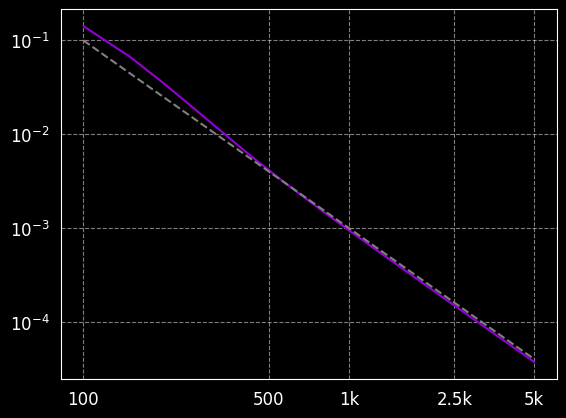

In [342]:
max_errors_per_T = [max(errors) for errors in errors_fidelity_list_full]
max_errorbound_per_T = [max(errors) for errors in error_full_list]

plt.figure()
plt.loglog(T1, max_errors_per_T,'-',color='darkviolet')
# plt.loglog(T1, max_errorbound_per_T,'-',color='orange')
plt.loglog(T1, 1000/T1**2, '--', label='Theoretical Slope', color='gray')
plt.xticks([100, 500, 1000, 2500, 5000], ['100', '500', '1k', '2.5k', '5k'])
plt.grid(True, ls="--", alpha=0.5)
plt.show()

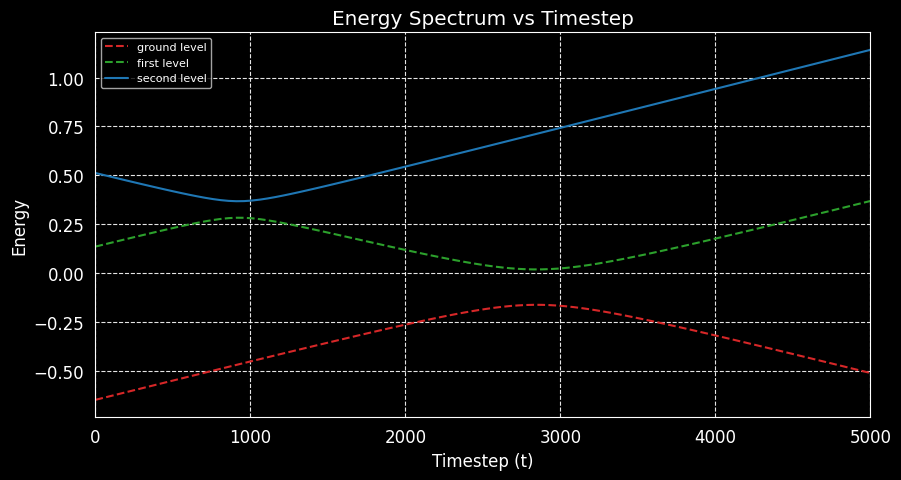

In [313]:
# #Spectrum vs T
plt.figure(figsize=(10,5))
plt.plot(listy[-1], ground_temp, color='tab:red', linestyle='--', label='ground level')
plt.plot(listy[-1],first_temp , color='tab:green', linestyle='--', label='first level')
plt.plot(listy[-1], second_temp, color='tab:blue', linestyle='-', label='second level')
plt.title('Energy Spectrum vs Timestep')
plt.xlabel('Timestep (t)')
plt.ylabel('Energy')
plt.legend(fontsize=8)
plt.autoscale(enable=True, axis='x', tight=True)
plt.grid(linestyle='--',alpha=0.9)


At T =  300.0


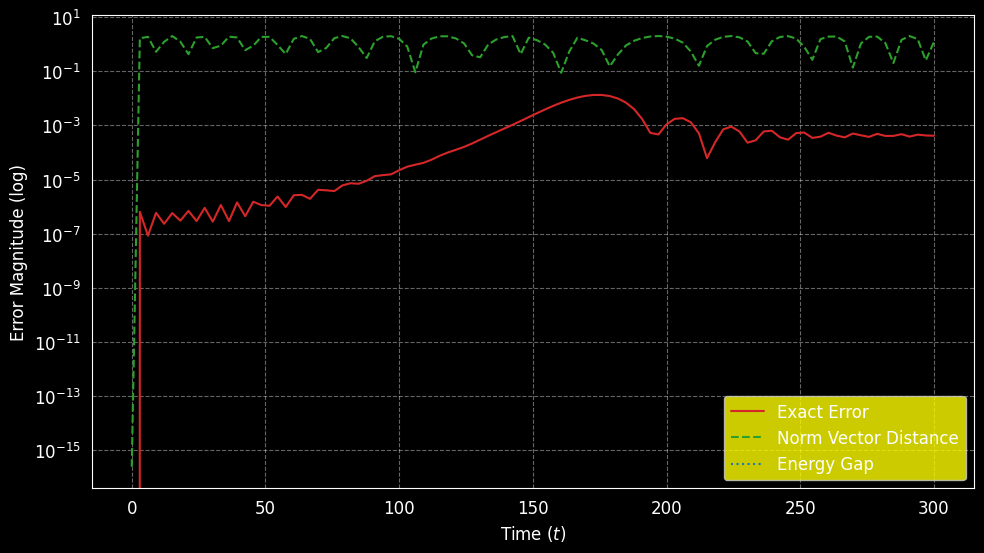

In [325]:
#Visulatization; Comparison of Error Metrics vs Energy Gap
k=2 
print('At T = ',T1[k])
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.set_xlabel('Time ($t$)', fontsize=12)
ax1.set_ylabel('Error Magnitude (log)', fontsize=12)
# Plotting both error metrics
ax1.plot(listy[k], errors_fidelity_list_full[k], color='tab:red', label='Exact Error')
ax1.plot(listy[k], errors_norm_full[k], color='tab:green', linestyle='--', label='Norm Vector Distance')
ax1.set_yscale('log') # Both metrics are best viewed on a log scale
ax1.grid(True, which="both", ls="--", alpha=0.4)

# Final formatting
fig.tight_layout(rect=[0, 0, 1, 0.95])

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, facecolor='yellow')

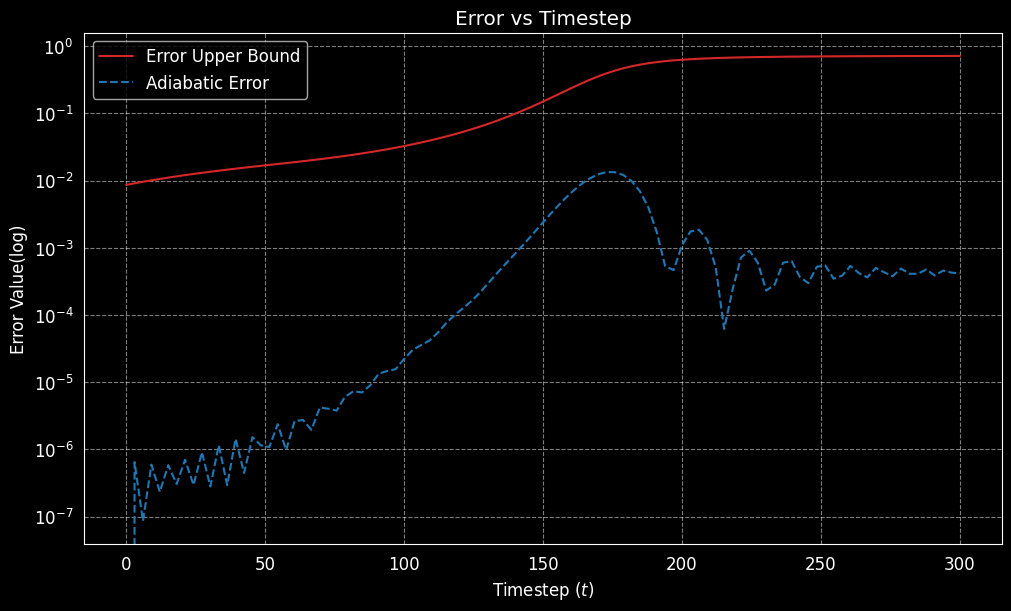

In [326]:
fig, ax = plt.subplots(figsize=(10,6),layout='constrained')
Approximate_Error= ax.plot(listy[k], error_full_list[k], color='tab:red',label='Error Upper Bound')
Ideal_Error=ax.plot(listy[k], errors_fidelity_list_full[k],'--', color='tab:blue',label='Adiabatic Error')
ax.set_ylabel('Error Value(log)', fontsize=12)
ax.set_xlabel('Timestep ($t$)', fontsize=12)
ax.set_yscale('log')
ax.legend()
ax.set_title('Error vs Timestep')
plt.grid(linestyle='--',alpha=0.5)

TO BE DELETED

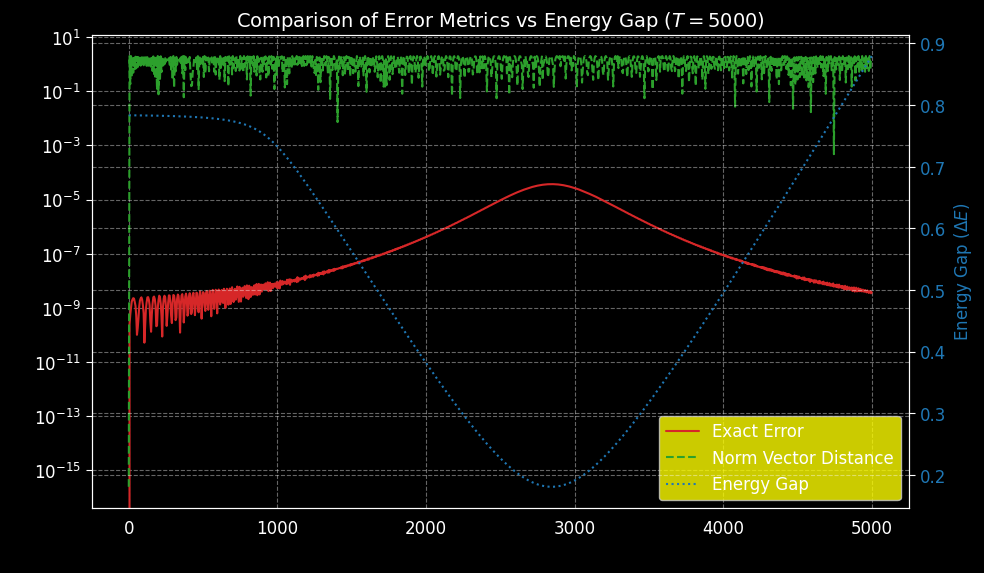

In [19]:
#Visulatization; Comparison of Error Metrics vs Energy Gap
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.set_xlabel('Time ($t$)', fontsize=12)
ax1.set_ylabel('Error Magnitude (log)', fontsize=12)

# Plotting both error metrics
ax1.plot(t_list, errors_fidelity, color='tab:red', label='Exact Error')
ax1.plot(t_list, errors_norm, color='tab:green', linestyle='--', label='Norm Vector Distance')
ax1.set_yscale('log') # Both metrics are best viewed on a log scale
ax1.grid(True, which="both", ls="--", alpha=0.4)

# Energy Gap on the second y-axis
ax2 = ax1.twinx()
ax2.set_ylabel(r'Energy Gap ($\Delta E$)', color='tab:blue', fontsize=12)
ax2.plot(t_list, gap, color='tab:blue', linestyle=':', label='Energy Gap')
ax2.tick_params(axis='y', labelcolor='tab:blue')
ax2.grid(True, which="both", ls="--", alpha=0.4)

# Final formatting
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.title(f'Comparison of Error Metrics vs Energy Gap ($T={T}$)', fontsize=14)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, facecolor='yellow')

# plt.savefig(f'/home/pravin/Desktop/Physik 2025/AQC Project/Comparison of Error Metrics vs Energy Gap (T={T}).png')
plt.show()

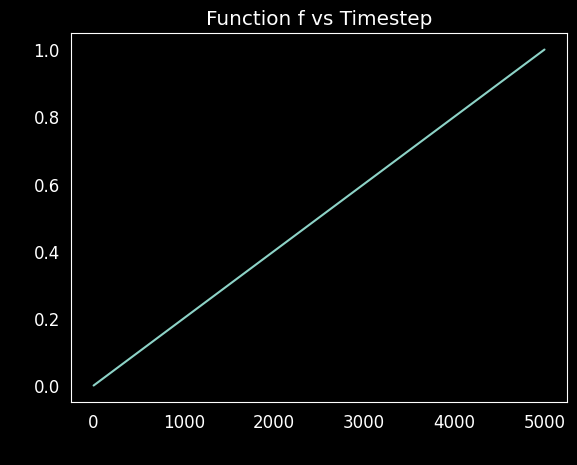

In [20]:
#for f vs T
f_values = [f(t, args) for t in t_list]
fidelity_values = [1 - err for err in errors_fidelity]
plt.figure()
plt.plot(t_list, f_values)
plt.title('Function f vs Timestep')
plt.xlabel('Timestep (t)')
plt.ylabel('f(t)')
plt.grid()
plt.show()

In [ ]:
max_error=np.argmax(error)
max_error_1=np.argmax(errors_fidelity)
time_at_error_peak=t_list[max_error]
error_value_at_peak=errors_fidelity[max_error_1]
error_upper_bound_value_at_peak=error[max_error]
Difference_in_error=error_value_at_peak-error_upper_bound_value_at_peak

print('Peak Error Time: ',time_at_error_peak)
print('Error: ',error_value_at_peak)
print('Upper Bound Error: ',error_upper_bound_value_at_peak)
print('Difference between Error and EUB: ',Difference_in_error)
